# FinSight: Microsoft Equity Analysis

This notebook applies the FinSight toolkit to Microsoft Corporation (`MSFT`).

The analysis covers:

- historical market data;
- descriptive price statistics;
- risk and return metrics;
- financial-statement performance;
- automated visualisations.

The analysis is educational and does not constitute investment advice.

In [85]:
!git clone https://github.com/dkhleung/FinSight.git
%cd FinSight
!pip install -q -r requirements.txt

fatal: destination path 'FinSight' already exists and is not an empty directory.
/content/FinSight/FinSight


In [86]:
from src.data_loader import download_stock_data
from src.financial_metrics import calculate_financial_metrics
from src.risk_metrics import calculate_risk_metrics
from src.visualization import create_stock_charts

from IPython.display import Image, display

In [87]:
%cd /content

!if [ -d "FinSight/.git" ]; then \
    cd FinSight && git pull; \
else \
    git clone https://github.com/dkhleung/FinSight.git; \
fi

%cd /content/FinSight

!pip install -q -r requirements.txt

/content
Already up to date.
/content/FinSight


In [88]:
from src.data_loader import download_stock_data
from src.financial_metrics import calculate_financial_metrics
from src.risk_metrics import calculate_risk_metrics
from src.visualization import create_stock_charts

from IPython.display import Image, display

print("FinSight modules imported successfully.")

FinSight modules imported successfully.


## 1. Market Data Collection

Microsoft Corporation (`MSFT`) is used as the initial case study.

The analysis uses five years of historical daily market data. The dataset
includes the trading date, opening price, highest price, lowest price, closing
price, and trading volume.

In [89]:
ticker = "MSFT"
analysis_period = "5y"

stock_data = download_stock_data(
    ticker=ticker,
    period=analysis_period,
)

print("Ticker:", ticker)
print("Analysis period:", analysis_period)
print("Number of observations:", len(stock_data))

Ticker: MSFT
Analysis period: 5y
Number of observations: 1254


In [90]:
stock_data.head()

,Date,Open,High,Low,Close,Volume
0,2021-07-28 00:00:00-04:00,288.989990,290.149994,283.829987,286.220001,33566900
1,2021-07-29 00:00:00-04:00,286.239990,288.619995,286.079987,286.500000,18168300
2,2021-07-30 00:00:00-04:00,285.170013,286.660004,283.910004,284.910004,20944800
3,2021-08-02 00:00:00-04:00,286.359985,286.769989,283.739990,284.820007,16267400
4,2021-08-03 00:00:00-04:00,285.420013,287.230011,284.000000,287.119995,17879000


The dataset contains one observation for each trading day. Non-trading days,
including weekends and market holidays, are not included.

The closing-price column will be used to calculate descriptive statistics,
returns, volatility, drawdown, and cumulative performance.

## 2. Descriptive Price Statistics

This section summarises Microsoft’s closing-price data over the selected
five-year period.

The statistics include the number of observations, average closing price,
minimum closing price, maximum closing price, and overall price change.

In [91]:
import pandas as pd

closing_prices = (
    stock_data["Close"]
    .dropna()
    .astype(float)
)

number_of_observations = len(closing_prices)

average_close = (
    sum(closing_prices) / number_of_observations
)

minimum_close = min(closing_prices)
maximum_close = max(closing_prices)

starting_close = float(closing_prices.iloc[0])
ending_close = float(closing_prices.iloc[-1])

overall_price_change = (
    ending_close / starting_close
) - 1

In [92]:
price_summary = pd.DataFrame(
    {
        "Metric": [
            "Number of observations",
            "Starting closing price",
            "Ending closing price",
            "Average closing price",
            "Minimum closing price",
            "Maximum closing price",
            "Overall price change",
        ],
        "Value": [
            number_of_observations,
            f"{starting_close:.2f}",
            f"{ending_close:.2f}",
            f"{average_close:.2f}",
            f"{minimum_close:.2f}",
            f"{maximum_close:.2f}",
            f"{overall_price_change:.2%}",
        ],
    }
)

price_summary

,Metric,Value
0,Number of observations,1254
1,Starting closing price,286.22
2,Ending closing price,389.10
3,Average closing price,366.79
4,Minimum closing price,214.25
5,Maximum closing price,542.07
6,Overall price change,35.94%


In [93]:
print("Descriptive Interpretation")
print("--------------------------")

print(
    f"Microsoft's closing price changed from "
    f"{starting_close:.2f} to {ending_close:.2f}."
)

print(
    f"This represents an overall price change of "
    f"{overall_price_change:.2%}."
)

print(
    f"The lowest closing price was {minimum_close:.2f}, "
    f"while the highest was {maximum_close:.2f}."
)

print(
    f"The average closing price during the period was "
    f"{average_close:.2f}."
)

Descriptive Interpretation
--------------------------
Microsoft's closing price changed from 286.22 to 389.10.
This represents an overall price change of 35.94%.
The lowest closing price was 214.25, while the highest was 542.07.
The average closing price during the period was 366.79.


The overall price change compares the first and final closing prices in the
dataset. It does not include dividends and therefore should not be interpreted
as total shareholder return.

The minimum and maximum values describe the observed closing-price range during
the selected period, while the average provides a basic measure of the central
price level.

## 3. Risk and Return Analysis

This section evaluates Microsoft’s historical return and risk characteristics
over the selected five-year period.

The analysis includes:

- annualized return;
- annualized volatility;
- maximum drawdown;
- Sharpe ratio.

The calculations are based on daily closing prices and assume 252 trading days
per year.

In [94]:
risk_results = calculate_risk_metrics(
    data=stock_data,
    risk_free_rate=0.0,
)

risk_results

{'annual_return': 0.06370514205551014,
 'annual_volatility': 0.2712171482092207,
 'maximum_drawdown': -0.3755646610503861,
 'sharpe_ratio': 0.23488611423038452}

In [95]:
risk_summary = pd.DataFrame(
    {
        "Metric": [
            "Annualized return",
            "Annualized volatility",
            "Maximum drawdown",
            "Sharpe ratio",
        ],
        "Value": [
            f"{risk_results['annual_return']:.2%}",
            f"{risk_results['annual_volatility']:.2%}",
            f"{risk_results['maximum_drawdown']:.2%}",
            f"{risk_results['sharpe_ratio']:.2f}",
        ],
    }
)

risk_summary

,Metric,Value
0,Annualized return,6.37%
1,Annualized volatility,27.12%
2,Maximum drawdown,-37.56%
3,Sharpe ratio,0.23


In [96]:
annual_return = risk_results["annual_return"]
annual_volatility = risk_results["annual_volatility"]
maximum_drawdown = risk_results["maximum_drawdown"]
sharpe_ratio = risk_results["sharpe_ratio"]

In [97]:
print("Risk and Return Interpretation")
print("------------------------------")

print(
    f"Microsoft generated an annualized return of "
    f"{annual_return:.2%} during the selected period."
)

print(
    f"Its annualized volatility was "
    f"{annual_volatility:.2%}."
)

print(
    f"The largest peak-to-trough decline was "
    f"{maximum_drawdown:.2%}."
)

print(
    f"The Sharpe ratio was "
    f"{sharpe_ratio:.2f}, assuming a 0% risk-free rate."
)

Risk and Return Interpretation
------------------------------
Microsoft generated an annualized return of 6.37% during the selected period.
Its annualized volatility was 27.12%.
The largest peak-to-trough decline was -37.56%.
The Sharpe ratio was 0.23, assuming a 0% risk-free rate.


### Interpretation

Annualized return measures the compounded yearly growth rate implied by the
daily price observations.

Annualized volatility measures the dispersion of daily returns after scaling
them to a yearly basis. A higher value indicates greater price uncertainty.

Maximum drawdown measures the largest decline from a previous price peak during
the analysis period. It provides an indication of the historical downside risk
experienced by an investor.

The Sharpe ratio compares excess return with volatility. In this analysis, the
risk-free rate is assumed to be 0%, so the result should be interpreted as a
simplified educational estimate rather than a complete institutional measure.

In [98]:
if sharpe_ratio >= 1:
    risk_assessment = (
        "The historical risk-adjusted return was relatively strong."
    )
elif sharpe_ratio > 0:
    risk_assessment = (
        "The historical risk-adjusted return was positive, "
        "but relatively modest."
    )
else:
    risk_assessment = (
        "The historical risk-adjusted return was negative."
    )

if maximum_drawdown <= -0.30:
    drawdown_assessment = (
        "The stock also experienced a substantial historical drawdown."
    )
else:
    drawdown_assessment = (
        "The historical drawdown remained below 30%."
    )

print(risk_assessment)
print(drawdown_assessment)

The historical risk-adjusted return was positive, but relatively modest.
The stock also experienced a substantial historical drawdown.


## 4. Financial Performance

This section examines Microsoft’s latest annual financial performance.

The analysis focuses on:

- total revenue;
- net income;
- year-over-year revenue growth;
- year-over-year net-income growth;
- net-profit margin.

Revenue and net income are presented in billions of US dollars.

In [99]:
financial_results = calculate_financial_metrics(
    ticker=ticker
)

financial_results

{'latest_revenue': 281724000000.0,
 'latest_net_income': 101832000000.0,
 'revenue_growth': 0.14932156232406713,
 'net_income_growth': 0.15539620586366532,
 'net_profit_margin': 0.3614601524896707}

In [100]:
latest_revenue = financial_results["latest_revenue"]
latest_net_income = financial_results["latest_net_income"]

revenue_growth = financial_results["revenue_growth"]
net_income_growth = financial_results["net_income_growth"]
net_profit_margin = financial_results["net_profit_margin"]

revenue_billions = latest_revenue / 1_000_000_000
net_income_billions = latest_net_income / 1_000_000_000

In [101]:
financial_summary = pd.DataFrame(
    {
        "Metric": [
            "Latest annual revenue",
            "Latest annual net income",
            "Revenue growth",
            "Net-income growth",
            "Net-profit margin",
        ],
        "Value": [
            f"USD {revenue_billions:,.2f} billion",
            f"USD {net_income_billions:,.2f} billion",
            f"{revenue_growth:.2%}",
            f"{net_income_growth:.2%}",
            f"{net_profit_margin:.2%}",
        ],
    }
)

financial_summary

,Metric,Value
0,Latest annual revenue,USD 281.72 billion
1,Latest annual net income,USD 101.83 billion
2,Revenue growth,14.93%
3,Net-income growth,15.54%
4,Net-profit margin,36.15%


In [102]:
print("Financial Performance Summary")
print("-----------------------------")

print(
    f"Microsoft reported annual revenue of "
    f"USD {revenue_billions:,.2f} billion."
)

print(
    f"Annual net income was "
    f"USD {net_income_billions:,.2f} billion."
)

print(
    f"Revenue increased by "
    f"{revenue_growth:.2%} year over year."
)

print(
    f"Net income increased by "
    f"{net_income_growth:.2%} year over year."
)

print(
    f"The latest net-profit margin was "
    f"{net_profit_margin:.2%}."
)

Financial Performance Summary
-----------------------------
Microsoft reported annual revenue of USD 281.72 billion.
Annual net income was USD 101.83 billion.
Revenue increased by 14.93% year over year.
Net income increased by 15.54% year over year.
The latest net-profit margin was 36.15%.


### Interpretation

Revenue growth indicates the rate at which the company’s annual sales changed
relative to the previous reporting period.

Net-income growth measures the change in earnings available after operating
costs, interest, taxes, and other expenses.

Net-profit margin measures how much net income was generated from each unit of
revenue. A higher margin generally indicates stronger profitability, although
meaningful interpretation should also consider the company’s industry,
business model, accounting policies, and historical performance.

In [103]:
if revenue_growth > 0 and net_income_growth > 0:
    growth_assessment = (
        "Revenue and net income both increased in the latest period."
    )
elif revenue_growth > 0:
    growth_assessment = (
        "Revenue increased, but net income did not increase."
    )
elif net_income_growth > 0:
    growth_assessment = (
        "Net income increased despite weaker revenue performance."
    )
else:
    growth_assessment = (
        "Both revenue and net income declined in the latest period."
    )

if net_profit_margin >= 0.25:
    margin_assessment = (
        "The company recorded a relatively high net-profit margin."
    )
elif net_profit_margin > 0:
    margin_assessment = (
        "The company remained profitable, with a positive net margin."
    )
else:
    margin_assessment = (
        "The company recorded a negative net-profit margin."
    )

print(growth_assessment)
print(margin_assessment)

Revenue and net income both increased in the latest period.
The company recorded a relatively high net-profit margin.


### Data Limitation

The financial-statement figures are retrieved from publicly available data
through `yfinance`. They may be delayed, reformatted, incomplete, or revised
after publication.

This analysis should therefore be treated as an educational demonstration
rather than a substitute for reviewing Microsoft’s official annual report and
regulatory filings.

## 5. Market Visualisations

This section presents three visualisations of Microsoft’s five-year market
performance:

1. historical closing price;
2. cumulative return;
3. drawdown from previous price peaks.

The charts are generated automatically using the reusable functions contained
in the FinSight `visualization.py` module.

In [104]:
chart_files = create_stock_charts(
    data=stock_data,
    ticker=ticker,
)

print("Charts created successfully:")

for file_name in chart_files:
    print(file_name)

Charts created successfully:
outputs/MSFT_price.png
outputs/MSFT_cumulative_return.png
outputs/MSFT_drawdown.png


### 5.1 Historical Closing Price

The historical closing-price chart shows how Microsoft’s share price changed
throughout the selected five-year period.

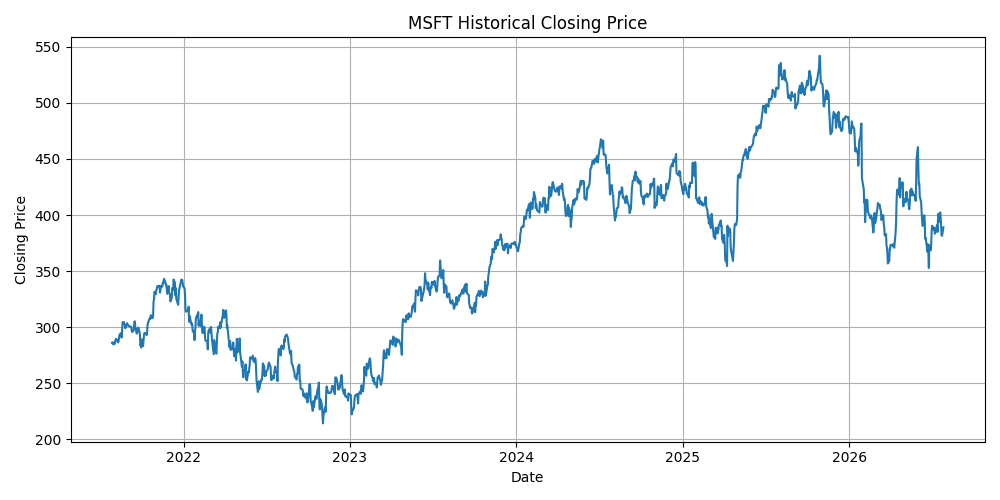

In [105]:
display(
    Image(filename=chart_files[0])
)

The chart illustrates both the longer-term price trend and periods of temporary
decline. Although the closing price changed considerably during the period, the
path was not linear and included several phases of volatility.

The chart should be interpreted together with the return, volatility, and
drawdown metrics rather than as an independent investment signal.

### 5.2 Cumulative Return

Cumulative return measures the percentage change in the investment value
relative to the first closing price in the dataset.

A value above zero represents a gain relative to the starting point, while a
value below zero represents a loss.

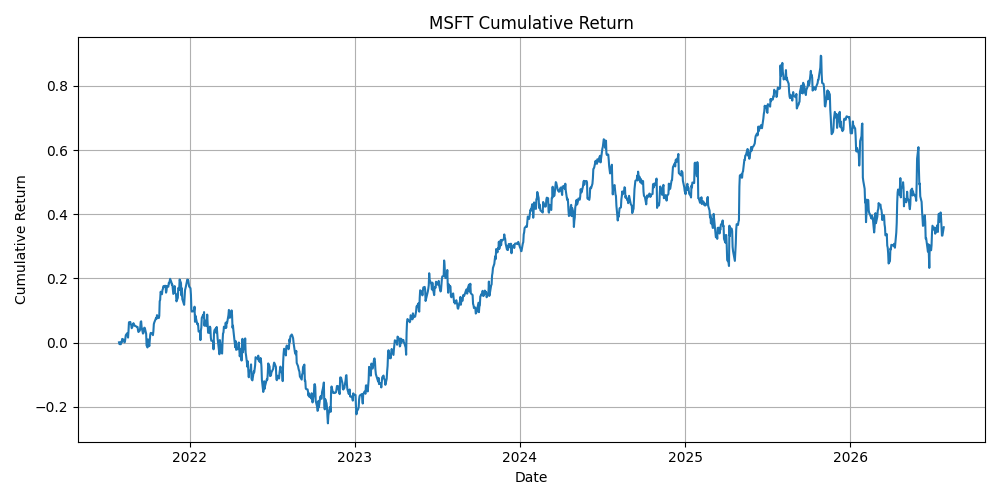

In [106]:
display(
    Image(filename=chart_files[1])
)

In [107]:
daily_returns = (
    stock_data["Close"]
    .pct_change()
    .fillna(0)
)

cumulative_returns = (
    (1 + daily_returns).cumprod()
) - 1

final_cumulative_return = float(
    cumulative_returns.iloc[-1]
)

print(
    f"Final cumulative return: "
    f"{final_cumulative_return:.2%}"
)

Final cumulative return: 35.94%


The cumulative-return chart shows how an investment made at the beginning of
the period would have changed over time, based only on closing-price movements.

The calculation excludes dividends, transaction costs, taxes, and currency
effects. It therefore represents price return rather than total shareholder
return.

### 5.3 Drawdown

Drawdown measures the percentage decline from the highest closing price
previously reached.

A value of zero indicates that the stock is at a new historical peak within the
selected period. Negative values indicate that the stock remains below its
previous peak.

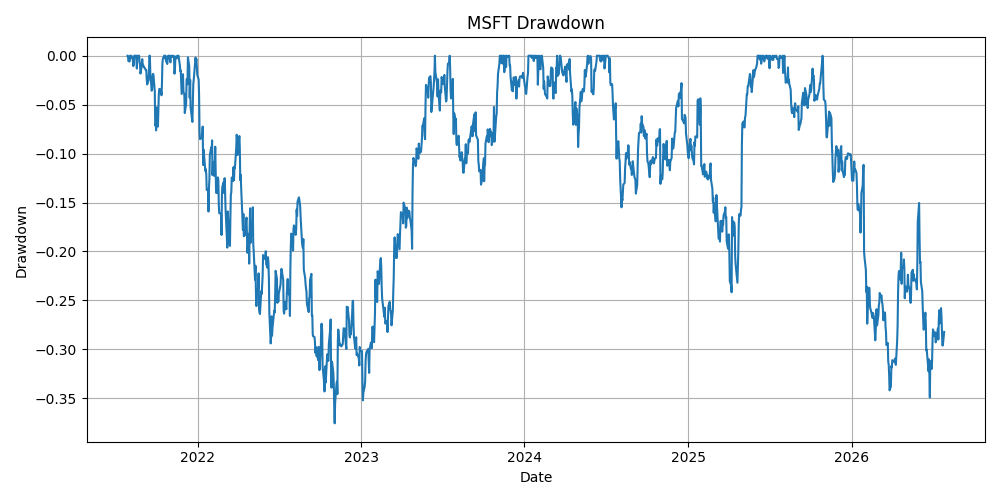

In [108]:
display(
    Image(filename=chart_files[2])
)

In [109]:
drawdown_data = stock_data[
    ["Date", "Close"]
].copy()

drawdown_data["Date"] = pd.to_datetime(
    drawdown_data["Date"]
)

drawdown_data["Close"] = pd.to_numeric(
    drawdown_data["Close"],
    errors="coerce",
)

drawdown_data = drawdown_data.dropna()

running_peak = drawdown_data["Close"].cummax()

drawdown_series = (
    drawdown_data["Close"] / running_peak
) - 1

worst_drawdown_position = drawdown_series.idxmin()

worst_drawdown = float(
    drawdown_series.loc[worst_drawdown_position]
)

worst_drawdown_date = drawdown_data.loc[
    worst_drawdown_position,
    "Date",
]

print(
    f"Worst drawdown: {worst_drawdown:.2%}"
)

print(
    f"Worst drawdown date: "
    f"{worst_drawdown_date.date()}"
)

Worst drawdown: -37.56%
Worst drawdown date: 2022-11-03


The lowest point in the drawdown chart represents the largest historical
peak-to-trough decline during the selected period.

Drawdown is particularly useful because it shows the scale of losses that may
be hidden when only the starting and ending prices are compared. However, past
drawdowns do not predict the timing or magnitude of future losses.

## 6. Overall Findings

This section combines the market-performance, risk, and financial-statement
results into a concise summary.

The analysis is descriptive rather than predictive. It evaluates Microsoft
using historical public data and does not produce a buy, hold, or sell
recommendation.

In [110]:
final_summary = pd.DataFrame(
    {
        "Category": [
            "Market Performance",
            "Market Performance",
            "Risk",
            "Risk",
            "Financial Performance",
            "Financial Performance",
            "Profitability",
        ],
        "Metric": [
            "Overall price change",
            "Annualized return",
            "Annualized volatility",
            "Maximum drawdown",
            "Revenue growth",
            "Net-income growth",
            "Net-profit margin",
        ],
        "Value": [
            f"{overall_price_change:.2%}",
            f"{annual_return:.2%}",
            f"{annual_volatility:.2%}",
            f"{maximum_drawdown:.2%}",
            f"{revenue_growth:.2%}",
            f"{net_income_growth:.2%}",
            f"{net_profit_margin:.2%}",
        ],
    }
)

final_summary

,Category,Metric,Value
0,Market Performance,Overall price change,35.94%
1,Market Performance,Annualized return,6.37%
2,Risk,Annualized volatility,27.12%
3,Risk,Maximum drawdown,-37.56%
4,Financial Performance,Revenue growth,14.93%
5,Financial Performance,Net-income growth,15.54%
6,Profitability,Net-profit margin,36.15%


In [111]:
summary_points = []

if annual_return > 0:
    summary_points.append(
        "Microsoft produced a positive annualized price return "
        "during the selected period."
    )
else:
    summary_points.append(
        "Microsoft produced a negative annualized price return "
        "during the selected period."
    )

if annual_volatility >= 0.25:
    summary_points.append(
        "Historical share-price volatility was relatively substantial."
    )
else:
    summary_points.append(
        "Historical share-price volatility remained below 25%."
    )

if maximum_drawdown <= -0.30:
    summary_points.append(
        "The stock experienced a peak-to-trough decline exceeding 30%."
    )
else:
    summary_points.append(
        "The maximum historical drawdown remained below 30%."
    )

if revenue_growth > 0 and net_income_growth > 0:
    summary_points.append(
        "The latest annual results showed growth in both revenue "
        "and net income."
    )
else:
    summary_points.append(
        "Revenue and net-income growth were not both positive."
    )

if net_profit_margin >= 0.25:
    summary_points.append(
        "The company recorded a comparatively strong net-profit margin."
    )
else:
    summary_points.append(
        "The company recorded a positive but more moderate net-profit margin."
    )

print("Overall Findings")
print("----------------")

for point in summary_points:
    print("-", point)

Overall Findings
----------------
- Microsoft produced a positive annualized price return during the selected period.
- Historical share-price volatility was relatively substantial.
- The stock experienced a peak-to-trough decline exceeding 30%.
- The latest annual results showed growth in both revenue and net income.
- The company recorded a comparatively strong net-profit margin.


### Conclusion

The FinSight analysis shows that company performance should not be evaluated
using share-price movement alone.

Microsoft's historical results combine positive long-term price performance
and strong financial profitability with meaningful market volatility and
drawdown risk. The risk metrics demonstrate that even a profitable and
financially established company can experience substantial temporary declines.

The financial-statement analysis provides evidence of the company's recent
growth and profitability, while the market analysis illustrates how investors
experienced that performance through changes in the share price.

A more complete investment assessment would also require valuation analysis,
benchmark comparison, competitive analysis, cash-flow examination, and
consideration of future business risks.

## 7. Methodology and Limitations

### Methodology

- Daily closing-price data is used for the market analysis.
- Returns are calculated from consecutive closing prices.
- Annualized calculations assume 252 trading days per year.
- Maximum drawdown is measured relative to previous price peaks.
- The Sharpe ratio assumes a 0% risk-free rate.
- Financial growth compares the latest available annual period with the
  previous annual period.

### Limitations

- Price returns exclude dividends and therefore do not represent total
  shareholder return.
- Transaction costs, taxation, inflation, and currency effects are excluded.
- The risk-free-rate assumption is simplified.
- Public data obtained through third-party services may be delayed, incomplete,
  reformatted, or subsequently revised.
- The analysis does not yet compare Microsoft with a market benchmark or peers.
- Valuation ratios and forward-looking forecasts are outside the current scope.
- Historical results do not predict future performance.

## 8. Project Takeaway

This case study demonstrates how FinSight converts public market and
financial-statement data into a structured equity-analysis workflow.

The project applies:

- modular Python programming;
- input and data validation;
- financial and statistical calculations;
- automated visualisation;
- conditional interpretation;
- reproducible notebook documentation.

FinSight is an educational portfolio project and does not provide investment
advice.“